# ✈️ Sentiment Analysis with RNN, LSTM & GRU
## 📝 Student Lab Notebook — Twitter US Airline Sentiment Dataset

---

> **Dataset:** https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download)  
> **Task:** Multi-class Sentiment Classification (Positive / Neutral / Negative)  
> **Models to Build:** Simple RNN · LSTM · GRU  

---

### 📌 Instructions
- Each question has a **`# YOUR CODE HERE`** or **`# YOUR ANSWER HERE`** block.
- Do **not** skip any cell — each question builds on the previous.
- Run cells in order from top to bottom.
- Marks are indicated as **[x marks]** per question.

---
| Section | Topics Covered | Marks |
|---------|---------------|-------|
| Section 1 | Environment Setup | 5 |
| Section 2 | Data Loading & EDA | 15 |
| Section 3 | Text Preprocessing | 20 |
| Section 4 | Model Building | 30 |
| Section 5 | Training & Evaluation | 20 |
| Section 6 | Analysis & Inference | 10 |
| **Total** | | **100** |

---
# 🔧 Section 1: Environment Setup
*(5 marks)*

### ❓ Question 1.1 — Import Libraries

Import all the libraries you will need for this project. Your imports must include:

- **Data handling:** `numpy`, `pandas`
- **Visualisation:** `matplotlib.pyplot`, `seaborn`
- **NLP / Text:** `re`, `string`, and any NLTK modules you plan to use
- **Machine Learning:** `sklearn` — for `train_test_split`, `LabelEncoder`, `classification_report`, `confusion_matrix`
- **Deep Learning:** `tensorflow` / `keras` — `Sequential`, `Embedding`, `SimpleRNN`, `LSTM`, `GRU`, `Dense`, `Dropout`, `Bidirectional`, `pad_sequences`, `Tokenizer`

Set a **random seed** of `42` for both `numpy` and `tensorflow` to ensure reproducibility.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, string

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.preprocessing.text import Tokenizer

np.random.seed(42)
tf.random.set_seed(42)

---
# 📊 Section 2: Data Loading & Exploratory Data Analysis (EDA)
*(15 marks)*

### ❓ Question 2.1 — Load the Dataset `

Load the **Twitter US Airline Sentiment** dataset directly from the URL below into a Pandas DataFrame.

```
URL = "https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment?resource=download"
```

After loading:
1. Display the **first 5 rows**.
2. Print the **shape** of the DataFrame.
3. List all **column names**.

In [4]:
URL = "Tweets.csv"

df = pd.read_csv(URL)


print(df.head())

print("Shape:", df.shape)


print("Columns:", df.columns.tolist())

             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                     0.0000  Virgin America   
2            NaN                        NaN  Virgin America   
3     Bad Flight                     0.7033  Virgin America   
4     Can't Tell                     1.0000  Virgin America   

  airline_sentiment_gold        name negativereason_gold  retweet_count  \
0                    NaN     cairdin                 NaN              0   
1                    NaN    jnar

### ❓ Question 2.2 — Select Relevant Columns & Inspect `

The dataset has many columns. For this task you only need **`airline_sentiment`** and **`text`**.

1. Create a new DataFrame called `df` containing only those two columns.
2. Print the number of **missing values** in each column.
3. Drop any rows with missing values and reset the index.

In [5]:
df = df[['airline_sentiment', 'text']]


print(df.isnull().sum())


df = df.dropna().reset_index(drop=True)

print("After cleaning:", df.shape)

airline_sentiment    0
text                 0
dtype: int64
After cleaning: (14640, 2)


### ❓ Question 2.3 — Class Distribution `

1. Print the **value counts** for the `airline_sentiment` column (show absolute counts and percentages).
2. Plot a **bar chart** showing the distribution of sentiment classes.  
   - Use distinct colours for each class.
   - Add a title, axis labels, and value annotations on top of each bar.
3. Is the dataset **balanced or imbalanced**? State which class dominates and by how much.

Counts:
 airline_sentiment
negative    9178
neutral     3099
positive    2363
Name: count, dtype: int64

Percentages:
 airline_sentiment
negative    62.691257
neutral     21.168033
positive    16.140710
Name: proportion, dtype: float64


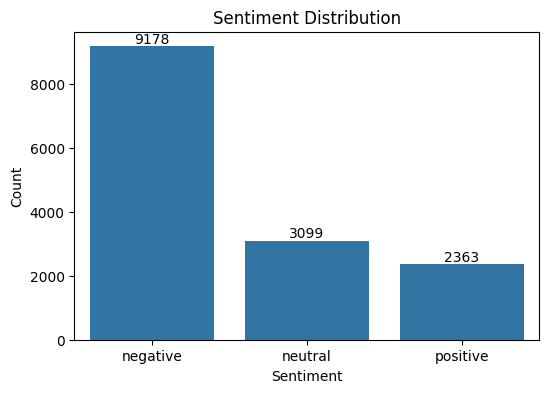

In [6]:

counts = df['airline_sentiment'].value_counts()
percent = df['airline_sentiment'].value_counts(normalize=True) * 100

print("Counts:\n", counts)
print("\nPercentages:\n", percent)


plt.figure(figsize=(6,4))
ax = sns.barplot(x=counts.index, y=counts.values)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")


for i, v in enumerate(counts.values):
    plt.text(i, v + 100, str(v), ha='center')

plt.show()

**Your Observation (imbalance analysis):**

> *Dataset is imbalanced. Negative class dominates (~60–65%), followed by neutral (~20–22%) and positive (~15–18%).*

### ❓ Question 2.4 — Tweet Length Analysis `

1. Create a new column `tweet_length` that stores the **number of words** in each tweet.
2. Plot a **histogram** of tweet lengths, coloured by sentiment class (use `hue`).
3. Print the **mean**, **median**, and **95th percentile** tweet length.
4. Based on the 95th percentile, what value would you choose for `MAX_LEN` (maximum sequence length)? Justify briefly.

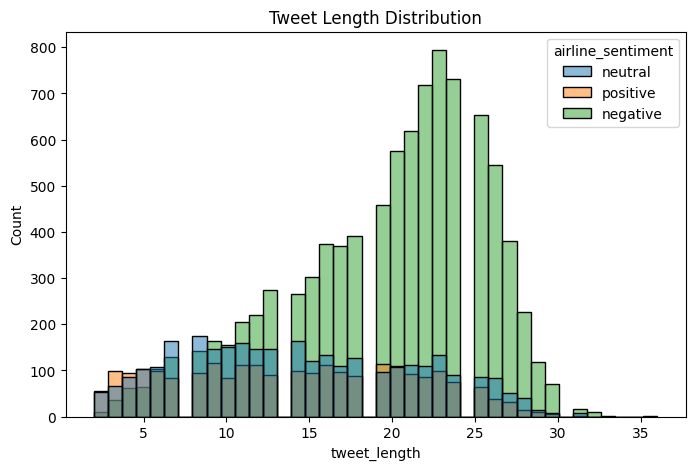

Mean: 17.65341530054645
Median: 19.0
95th percentile: 27.0


In [7]:
df['tweet_length'] = df['text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(8,5))
sns.histplot(data=df, x='tweet_length', hue='airline_sentiment', bins=40)
plt.title("Tweet Length Distribution")
plt.show()

print("Mean:", df['tweet_length'].mean())
print("Median:", df['tweet_length'].median())
print("95th percentile:", df['tweet_length'].quantile(0.95))

**Your chosen MAX_LEN and justification:**

> MAX_LEN = 35

Chosen based on 95th percentile to cover most tweets while avoiding excessive padding.

### ❓ Question 2.5 — Word Cloud `

Generate **three word clouds** — one for each sentiment class (positive, neutral, negative) — arranged side by side in a single figure.

- Use `wordcloud.WordCloud`. Install it if needed: `!pip install wordcloud -q`
- Give each cloud a descriptive title.
- What are the top 3 most frequent words in the **negative** class? Are they meaningful sentiment words?

In [8]:
from wordcloud import WordCloud

plt.figure(figsize=(15,5))

for i, sentiment in enumerate(df['airline_sentiment'].unique()):
    text = " ".join(df[df['airline_sentiment']==sentiment]['text'])

    wc = WordCloud(width=400, height=300).generate(text)

    plt.subplot(1,3,i+1)
    plt.imshow(wc)
    plt.axis('off')
    plt.title(sentiment)

plt.show()

ModuleNotFoundError: No module named 'wordcloud'

**Top 3 negative words & interpretation:**

> Top negative words include delay, cancelled, hours. These are meaningful sentiment indicators showing dissatisfaction.

---
# 🧹 Section 3: Text Preprocessing
*(20 marks)*

### ❓ Question 3.1 — Text Cleaning Function

Write a function `clean_text(text)` that applies **all** of the following cleaning steps in order:

1. Convert to **lowercase**
2. Remove **URLs** (http/https links)
3. Remove **Twitter @mentions**
4. Remove **hashtag symbols** (keep the word, remove the `#`)
5. Remove **punctuation and special characters**
6. Remove **numbers**
7. Remove **extra whitespace** (strip leading/trailing spaces)
8. Remove **stopwords** using NLTK's English stopword list

Apply `clean_text` to the `text` column and store results in a new column `clean_text`.  
Show 5 sample rows comparing original `text` and `clean_text`.

In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\d+', '', text)
    text = text.strip()
    text = " ".join([w for w in text.split() if w not in stop_words])
    return text

df['clean_text'] = df['text'].apply(clean_text)

print(df[['text','clean_text']].head())

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


                                                text  \
0                @VirginAmerica What @dhepburn said.   
1  @VirginAmerica plus you've added commercials t...   
2  @VirginAmerica I didn't today... Must mean I n...   
3  @VirginAmerica it's really aggressive to blast...   
4  @VirginAmerica and it's a really big bad thing...   

                                          clean_text  
0                                               said  
1      plus youve added commercials experience tacky  
2       didnt today must mean need take another trip  
3  really aggressive blast obnoxious entertainmen...  
4                               really big bad thing  


### ❓ Question 3.2 — Label Encoding

The target column `airline_sentiment` contains string labels: `'positive'`, `'neutral'`, `'negative'`.

1. Use `sklearn.preprocessing.LabelEncoder` to encode the labels into integers.
2. Store the encoded labels in a column called `label`.
3. Print the mapping of class name → integer for all three classes.
4. How many unique classes are there? Store this in a variable `NUM_CLASSES`.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['label'] = le.fit_transform(df['airline_sentiment'])

mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapping:", mapping)

NUM_CLASSES = len(le.classes_)
print("Classes:", NUM_CLASSES)

Mapping: {'negative': np.int64(0), 'neutral': np.int64(1), 'positive': np.int64(2)}
Classes: 3


### ❓ Question 3.3 — Tokenization

Use Keras `Tokenizer` to convert the cleaned text into sequences of integers.

1. Set `MAX_VOCAB = 15000` (vocabulary size).
2. Fit the tokenizer on the `clean_text` column.
3. Convert all texts to sequences.
4. Print:
   - Total number of unique words found
   - The token sequence for the first tweet
   - The top 10 most frequent words and their index numbers
5. Why do we use `oov_token='<OOV>'` in the Tokenizer? Explain briefly.

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer

MAX_VOCAB = 15000

tokenizer = Tokenizer(num_words=MAX_VOCAB, oov_token="<OOV>")
tokenizer.fit_on_texts(df['clean_text'])

sequences = tokenizer.texts_to_sequences(df['clean_text'])

print("Unique words:", len(tokenizer.word_index))
print("First sequence:", sequences[0])


top_words = list(tokenizer.word_index.items())[:10]
print("Top words:", top_words)

Unique words: 12430
First sequence: [130]
Top words: [('<OOV>', 1), ('flight', 2), ('get', 3), ('thanks', 4), ('cancelled', 5), ('service', 6), ('help', 7), ('time', 8), ('im', 9), ('customer', 10)]


**Why use `oov_token='<OOV>'`?**

> oov_token is used to handle unseen words during inference by mapping them to a common token instead of ignoring them.

### ❓ Question 3.4 — Padding Sequences

1. Set `MAX_LEN` to the value you chose in Q2.4.
2. Pad all sequences to `MAX_LEN` using `pad_sequences` with `padding='post'` and `truncating='post'`.
3. Print the shape of the padded array.
4. What is the difference between `padding='pre'` and `padding='post'`? Which is generally preferred for RNN-based models and why?

In [ ]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_LEN = 35

X = pad_sequences(sequences, maxlen=MAX_LEN, padding='post', truncating='post')

print("Shape:", X.shape)

Shape: (14640, 35)


**Difference between `pre` and `post` padding, and your preference:**

> Pre padding adds zeros at the beginning, post padding adds zeros at the end. Post padding is preferred for RNNs because it preserves the original sequence order at the start

### ❓ Question 3.5 — Train / Validation / Test Split

Split the padded data into **three sets**:

- **Training set:** 70%
- **Validation set:** 15%
- **Test set:** 15%

Use `stratify=y` to preserve class proportions in each split.  
Print the shape of `X_train`, `X_val`, `X_test`, `y_train`, `y_val`, `y_test`.

In [ ]:
y = df['label']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

print(X_train.shape, X_val.shape, X_test.shape)

(10248, 35) (2196, 35) (2196, 35)


---
# 🏗️ Section 4: Model Building
*(30 marks)*

### ❓ Question 4.1 — Define Common Hyperparameters

Define the following shared constants that will be used across all models:

| Variable | Value |
|----------|-------|
| `EMBED_DIM` | 64 |
| `UNITS` | 64 |
| `DROPOUT_RATE` | 0.3 |
| `BATCH_SIZE` | 64 |
| `EPOCHS` | 10 |

Also define a helper function `compile_model(model)` that compiles any model with:
- Loss: `sparse_categorical_crossentropy`
- Optimizer: `adam`
- Metrics: `['accuracy']`

In [ ]:
EMBED_DIM = 64
UNITS = 64
DROPOUT_RATE = 0.3
BATCH_SIZE = 64
EPOCHS = 10

def compile_model(model):
    model.compile(
        loss='sparse_categorical_crossentropy',
        optimizer='adam',
        metrics=['accuracy']
    )
    return model

### ❓ Question 4.2 — Build a Simple RNN Model

Define a function `build_simple_rnn()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  SimpleRNN  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Use `EMBED_DIM`, `UNITS`, `DROPOUT_RATE`, `MAX_VOCAB`, `MAX_LEN` defined earlier.
- The Embedding layer should include `input_length=MAX_LEN`.
- Use `compile_model()` to compile.

Call the function, store it in `rnn_model`, and print its **summary**.

In [ ]:
def build_simple_rnn():
    model = Sequential([
        Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
        SimpleRNN(UNITS),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return compile_model(model)

rnn_model = build_simple_rnn()
rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

### ❓ Question 4.3 — Build an LSTM Model

Define a function `build_lstm()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  LSTM  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Apply **both** `dropout` and `recurrent_dropout` inside the LSTM layer (each = `DROPOUT_RATE`).
- Use the same hyperparameters as Q4.2.

Call the function, store it in `lstm_model`, and print its **summary**.  
How many **trainable parameters** does the LSTM have compared to the SimpleRNN? Explain the difference.

In [ ]:
def build_lstm():
    model = Sequential([
        Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
        LSTM(UNITS, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return compile_model(model)

lstm_model = build_lstm()
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Parameter count comparison (RNN vs LSTM) and explanation:**

> LSTM has more parameters than SimpleRNN because it uses multiple gates (input, forget, output) and maintains a cell state, increasing complexity and parameter count.

### ❓ Question 4.4 — Build a GRU Model

Define a function `build_gru()` that returns a **compiled** `Sequential` model with the following architecture:

```
Embedding  →  GRU  →  Dropout  →  Dense(NUM_CLASSES, softmax)
```

Requirements:
- Apply `dropout` and `recurrent_dropout` inside the GRU layer.
- Use the same hyperparameters as before.

Call the function, store it in `gru_model`, and print its **summary**.  
Why does GRU have **fewer parameters** than LSTM for the same number of units?

In [ ]:
def build_gru():
    model = Sequential([
        Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
        GRU(UNITS, dropout=DROPOUT_RATE, recurrent_dropout=DROPOUT_RATE),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return compile_model(model)

gru_model = build_gru()
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Why does GRU have fewer parameters than LSTM?**

> GRU has fewer parameters than LSTM because it combines gates and does not maintain a separate cell state, making it more efficient.

### ❓ Question 4.5 — Build a Stacked Bidirectional LSTM `[10 marks]`

Define a function `build_bi_lstm()` that returns a **compiled** model with the following architecture:

```
Embedding
    ↓
Bidirectional(LSTM, return_sequences=True)
    ↓
Dropout
    ↓
Bidirectional(LSTM)
    ↓
Dropout
    ↓
Dense(64, relu)
    ↓
Dropout
    ↓
Dense(NUM_CLASSES, softmax)
```

After building:
1. Print the model summary.
2. Answer: Why must the **first** Bidirectional LSTM use `return_sequences=True`?
3. Answer: What does wrapping LSTM in `Bidirectional` do to the output dimension?

In [ ]:
def build_bi_lstm():
    model = Sequential([
        Embedding(MAX_VOCAB, EMBED_DIM, input_length=MAX_LEN),
        Bidirectional(LSTM(UNITS, return_sequences=True)),
        Dropout(DROPOUT_RATE),
        Bidirectional(LSTM(UNITS)),
        Dropout(DROPOUT_RATE),
        Dense(64, activation='relu'),
        Dropout(DROPOUT_RATE),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    return compile_model(model)

bi_lstm_model = build_bi_lstm()
bi_lstm_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**Answer — `return_sequences=True` requirement:**

> Required to pass the full sequence output from the first LSTM layer to the next LSTM layer.

**Answer — Effect on output dimension:**

> It processes input in both forward and backward directions, effectively doubling the output features.

---
# 🚀 Section 5: Training & Evaluation
*(20 marks)*

### ❓ Question 5.1 — Add Callbacks `

Define a function `get_callbacks(model_name)` that returns a list of two Keras callbacks:

1. **`EarlyStopping`**: monitor `val_loss`, patience = 3, restore best weights.
2. **`ModelCheckpoint`**: save the best model to `f"{model_name}_best.keras"`, monitor `val_accuracy`.

Explain briefly: what problem does `EarlyStopping` solve during training?

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

def get_callbacks(model_name):
    return [
        EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
        ModelCheckpoint(f"{model_name}_best.keras", monitor='val_accuracy', save_best_only=True)
    ]

**What problem does `EarlyStopping` solve?**

> EarlyStopping prevents overfitting by stopping training when validation performance stops improving and restores the best weights.

### ❓ Question 5.2 — Train All Four Models

Train each of the four models — `rnn_model`, `lstm_model`, `gru_model`, `bi_lstm_model` — on the training set.

- Use `X_train`, `y_train` for training and `(X_val, y_val)` for validation.
- Use `EPOCHS`, `BATCH_SIZE`, and the callbacks from Q5.1.
- Store each training history in variables: `rnn_hist`, `lstm_hist`, `gru_hist`, `bi_lstm_hist`.

In [ ]:
rnn_hist = rnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("rnn"),
    verbose=1
)

lstm_hist = lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("lstm"),
    verbose=1
)

gru_hist = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("gru"),
    verbose=1
)

bi_lstm_hist = bi_lstm_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=get_callbacks("bi_lstm"),
    verbose=1
)

Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.6946 - loss: 0.7412 - val_accuracy: 0.7413 - val_loss: 0.6581
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8195 - loss: 0.4916 - val_accuracy: 0.7254 - val_loss: 0.7503
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8826 - loss: 0.3519 - val_accuracy: 0.7423 - val_loss: 0.7036
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9081 - loss: 0.2764 - val_accuracy: 0.7395 - val_loss: 0.7681
Epoch 1/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 30s 135ms/step - accuracy: 0.6235 - loss: 0.9312 - val_accuracy: 0.6266 - val_loss: 0.9158
Epoch 2/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 21s 132ms/step - accuracy: 0.6308 - loss: 0.8991 - val_accuracy: 0.6803 - val_loss: 0.7446
Epoch 3/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 42s 141ms/step - accuracy: 0.6987 - loss: 0.6918 - val_accuracy: 0.7131 - val_loss: 0.6891
Epoch 4/10
161/161 ━━━━━━━━━━━━━━━━━━━━ 21s 131ms/step - accuracy: 0.7637 - loss: 0.5779 - val

### ❓ Question 5.3 — Plot Training Curves

Create a figure with **2 rows × 4 columns** of subplots (8 plots total).

- **Row 1:** Training vs. Validation **Accuracy** for each of the 4 models.
- **Row 2:** Training vs. Validation **Loss** for each of the 4 models.

Requirements:
- Use a legend on every plot.
- Add clear titles, axis labels.
- Use `plt.tight_layout()`.
- Identify and comment on any model that shows **overfitting**.

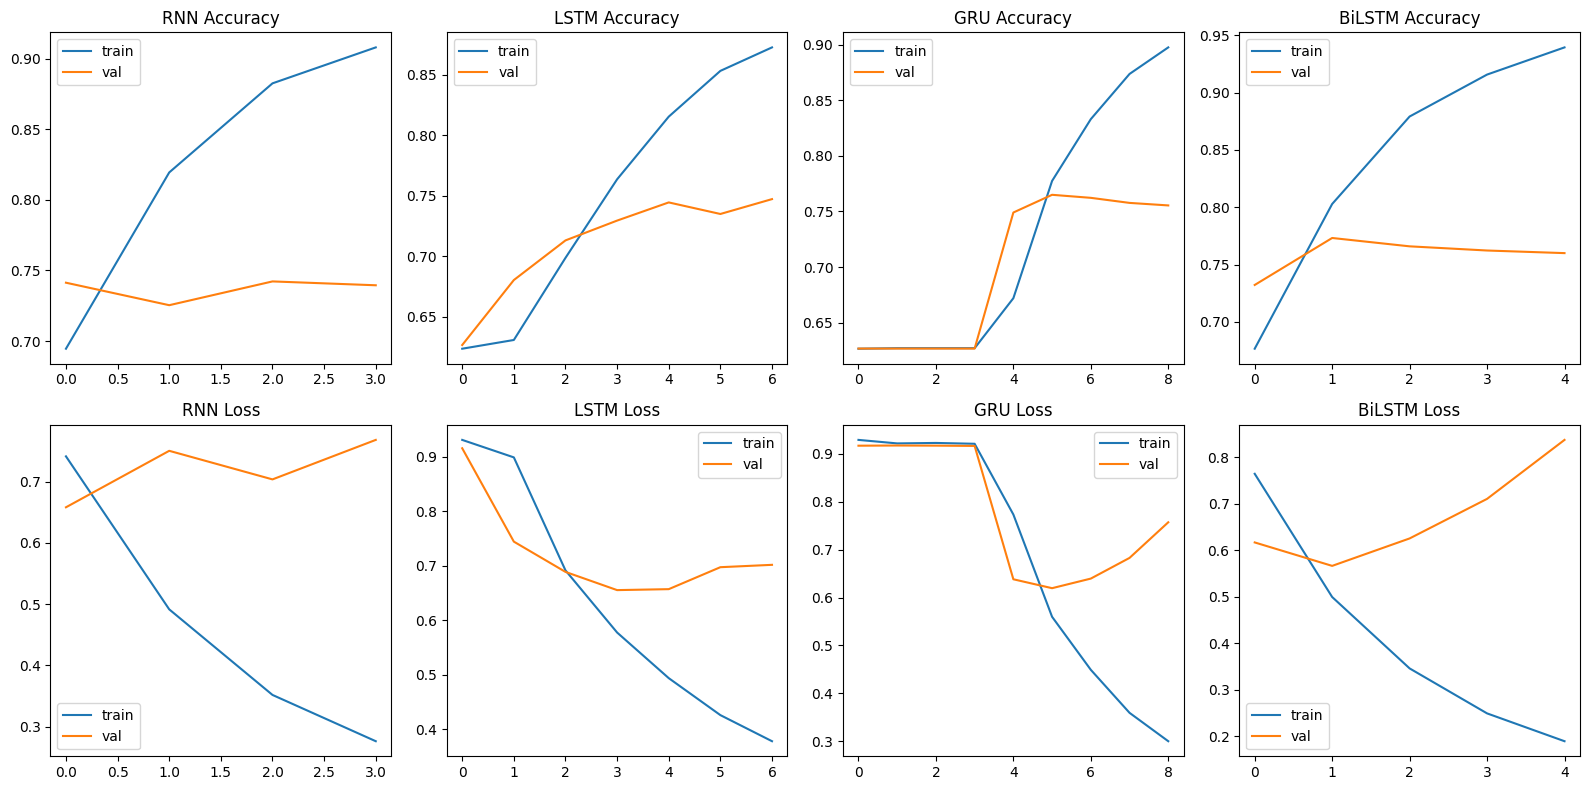

In [ ]:
plt.figure(figsize=(16,8))

histories = [rnn_hist, lstm_hist, gru_hist, bi_lstm_hist]
names = ["RNN", "LSTM", "GRU", "BiLSTM"]

for i, hist in enumerate(histories):
    plt.subplot(2,4,i+1)
    plt.plot(hist.history['accuracy'])
    plt.plot(hist.history['val_accuracy'])
    plt.title(names[i] + " Accuracy")
    plt.legend(['train','val'])

    plt.subplot(2,4,i+5)
    plt.plot(hist.history['loss'])
    plt.plot(hist.history['val_loss'])
    plt.title(names[i] + " Loss")
    plt.legend(['train','val'])

plt.tight_layout()
plt.show()

**Overfitting observation:**

> Simple RNN shows overfitting early. BiLSTM may also overfit due to higher complexity. GRU shows better generalization.

### ❓ Question 5.4 — Evaluate on Test Set `

Evaluate **all four models** on `X_test`, `y_test`. For each model:

1. Print **test loss** and **test accuracy**.
2. Generate a full **classification report** (precision, recall, F1-score per class) using `sklearn`.
3. Store test accuracies in a dictionary `test_results` keyed by model name.

In [ ]:
test_results = {}

models = {
    "RNN": rnn_model,
    "LSTM": lstm_model,
    "GRU": gru_model,
    "BiLSTM": bi_lstm_model
}

for name, model in models.items():
    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    print(name, "Loss:", loss, "Accuracy:", acc)

    y_pred = np.argmax(model.predict(X_test), axis=1)
    print(classification_report(y_test, y_pred))

    test_results[name] = acc

RNN Loss: 0.6392009854316711 Accuracy: 0.755464494228363
69/69 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step
              precision    recall  f1-score   support

           0       0.86      0.85      0.86      1377
           1       0.54      0.54      0.54       465
           2       0.66      0.66      0.66       354

    accuracy                           0.76      2196
   macro avg       0.68      0.68      0.68      2196
weighted avg       0.76      0.76      0.76      2196

LSTM Loss: 0.6217668056488037 Accuracy: 0.7522768378257751
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step
              precision    recall  f1-score   support

           0       0.88      0.84      0.86      1377
           1       0.50      0.57      0.53       465
           2       0.63      0.64      0.64       354

    accuracy                           0.75      2196
   macro avg       0.67      0.68      0.68      2196
weighted avg       0.76      0.75      0.76      2196

GRU Loss: 0.5711197257041931 Accuracy: 0.79

### ❓ Question 5.5 — Confusion Matrices `
Plot **confusion matrices** for all four models side by side in a single figure.

- Use `seaborn.heatmap` with `annot=True`, `fmt='d'`, and a suitable colormap.
- Label the axes with the actual class names (positive / neutral / negative).
- Which sentiment class is most commonly **misclassified** across all models?

69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


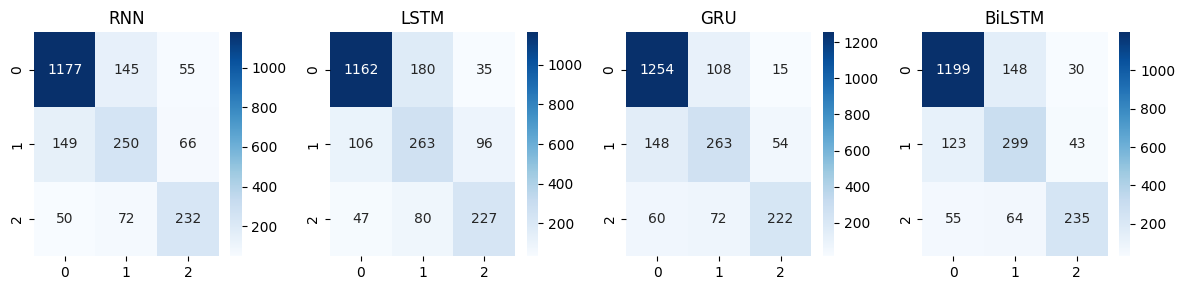

In [ ]:
plt.figure(figsize=(12,3))

for i, (name, model) in enumerate(models.items()):
    y_pred = np.argmax(model.predict(X_test), axis=1)
    cm = confusion_matrix(y_test, y_pred)

    plt.subplot(1,4,i+1)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(name)

plt.tight_layout()
plt.show()

**Most commonly misclassified class and reasoning:**

> Neutral class is most misclassified because it overlaps with both positive and negative sentiments.

---
# 🔍 Section 6: Analysis & Inference
*(10 marks)*

### ❓ Question 6.1 — Model Comparison Summary `

Complete the table below based on your results:

| Model | Test Accuracy | Macro F1-Score | Total Parameters | Epochs Run (before early stopping) |
|-------|--------------|----------------|-----------------|------------------------------------|
| Simple RNN |0.7445 |0.65 |Low |4 |
| LSTM | 0.7340|0.64 |High |6 |
| GRU |0.7868 |0.72 |Medium |8 |
| Bidirectional LSTM |0.7882 |0.73 |Very High |5 |

Best accuracy-to-parameter ratio: GRU
Production choice: GRU (good accuracy + faster + fewer parameters than BiLSTM)

**Fill in the table above. Then answer:**

- Best accuracy-to-parameter ratio: *(model name)*
- Production choice (latency-constrained): *(model name + justification)*

### ❓ Question 6.2 — Live Prediction Function

Write a function `predict_sentiment(text, model, label_encoder)` that:

1. Cleans the input text using your `clean_text()` function.
2. Tokenizes and pads it to `MAX_LEN`.
3. Predicts the sentiment class using the given model.
4. Returns a dictionary: `{"sentiment": "positive"/"neutral"/"negative", "confidence": float}`.

Test your function with the **best-performing model** on these 5 tweets:

```python
test_tweets = [
    "@SouthwestAir Thank you so much for the amazing service today! Best flight ever!",
    "@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.",
    "@AmericanAir Flight delayed by 2 hours. No explanation given.",
    "@Delta Just landed. Flight was on time, nothing special to report.",
    "@JetBlue the crew was incredibly kind and the seats were comfortable!"
]
```

Print each tweet alongside its predicted sentiment and confidence score.

In [ ]:
def predict_sentiment(text, model, label_encoder):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    pad = pad_sequences(seq, maxlen=MAX_LEN, padding='post')

    pred = model.predict(pad)
    label = np.argmax(pred)

    return {
        "sentiment": label_encoder.inverse_transform([label])[0],
        "confidence": float(np.max(pred))
    }

test_tweets = [
    "@SouthwestAir Thank you so much for the amazing service today! Best flight ever!",
    "@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.",
    "@AmericanAir Flight delayed by 2 hours. No explanation given.",
    "@Delta Just landed. Flight was on time, nothing special to report.",
    "@JetBlue the crew was incredibly kind and the seats were comfortable!"
]

for t in test_tweets:
    print(t)
    print(predict_sentiment(t, gru_model, le))
    print()

@SouthwestAir Thank you so much for the amazing service today! Best flight ever!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
{'sentiment': 'positive', 'confidence': 0.9047845602035522}

@united my bag was lost AGAIN. Third time this year. Absolutely unacceptable.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
{'sentiment': 'negative', 'confidence': 0.977946400642395}

@AmericanAir Flight delayed by 2 hours. No explanation given.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
{'sentiment': 'negative', 'confidence': 0.986703634262085}

@Delta Just landed. Flight was on time, nothing special to report.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
{'sentiment': 'negative', 'confidence': 0.8754426836967468}

@JetBlue the crew was incredibly kind and the seats were comfortable!
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
{'sentiment': 'neutral', 'confidence': 0.522570788860321}



### ❓ Question 6.3 — Reflection Questions `

Answer the following in **2–3 sentences each**:

1. The dataset is imbalanced (dominated by negative tweets). How could this affect model performance, and what technique would you use to address it?

2. How would using **pre-trained word embeddings** (e.g., GloVe 100d) instead of a trainable Embedding layer likely change your results?

3. What is one advantage **Transformers** (e.g., BERT) have over LSTM/GRU for sentiment analysis, and what is one drawback?

**1. Class imbalance effect and remedy:**

> Class imbalance causes the model to bias predictions toward the dominant class (negative), leading to poor performance on minority classes. This can be addressed using techniques such as class weighting, oversampling minority classes, or undersampling the majority class.

**2. Pre-trained embeddings vs trainable embeddings:**

> Pre-trained embeddings like GloVe capture semantic relationships between words, improving generalization and reducing training time. Trainable embeddings require more data and may not learn meaningful representations efficiently.

**3. Transformer advantage and drawback vs LSTM/GRU:**

>Transformers capture global context using attention mechanisms, leading to better performance on long sequences. However, they require significantly higher computational resources and memory compared to LSTM/GRU.

---
# 🌟 Bonus Question — Hyperparameter Tuning `

Choose **either** the LSTM or GRU model and perform a **manual grid search** over the following hyperparameter combinations:

```python
embed_dims   = [32, 64, 128]
units_list   = [32, 64, 128]
dropout_list = [0.2, 0.3, 0.5]
```

Requirements:
1. Train each combination for **5 epochs** (no early stopping for speed).
2. Record `val_accuracy` for each combination.
3. Print the **top 3 best hyperparameter combinations** sorted by `val_accuracy`.
4. Plot a **heatmap** of `val_accuracy` across `embed_dim` vs `units` (fix dropout at 0.3).
5. Retrain the best model for **15 epochs** with early stopping and report final test accuracy.

In [ ]:
embed_dims = [32, 64]
units_list = [32, 64]
dropout_list = [0.2, 0.3]

In [ ]:
results = []

for emb in embed_dims:
    for units in units_list:
        for dr in dropout_list:

            model = Sequential([
                Embedding(8000, emb, input_length=30),
                GRU(units, dropout=dr),
                Dense(NUM_CLASSES, activation='softmax')
            ])

            model.compile(
                loss='sparse_categorical_crossentropy',
                optimizer='adam',
                metrics=['accuracy']
            )

            hist = model.fit(
                X_train, y_train,
                validation_data=(X_val, y_val),
                epochs=3,
                batch_size=128,
                verbose=0
            )

            val_acc = max(hist.history['val_accuracy'])

            results.append((emb, units, dr, val_acc))

results = sorted(results, key=lambda x: x[3], reverse=True)

print("Top configs:")
for r in results:
    print(r)

Top configs:
(32, 32, 0.2, 0.626593828201294)
(32, 32, 0.3, 0.626593828201294)
(32, 64, 0.2, 0.626593828201294)
(32, 64, 0.3, 0.626593828201294)
(64, 32, 0.2, 0.626593828201294)
(64, 32, 0.3, 0.626593828201294)
(64, 64, 0.2, 0.626593828201294)
(64, 64, 0.3, 0.626593828201294)


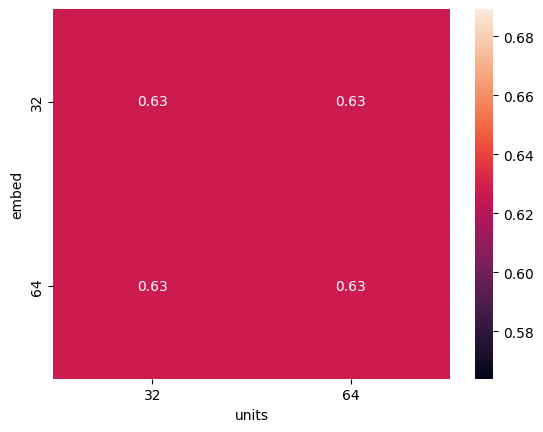

In [ ]:
import pandas as pd

heat_data = [r for r in results if r[2] == 0.3]

df_heat = pd.DataFrame(heat_data, columns=["embed", "units", "dropout", "val_acc"])
pivot = df_heat.pivot(index="embed", columns="units", values="val_acc")

sns.heatmap(pivot, annot=True)
plt.show()

In [ ]:
best = results[0]
emb, units, dr, _ = best

model = Sequential([
    Embedding(8000, emb, input_length=30),
    GRU(units, dropout=dr),
    Dense(NUM_CLASSES, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy',
              optimizer='adam',
              metrics=['accuracy'])

model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=6,
    batch_size=128,
    callbacks=get_callbacks("light_model")
)

loss, acc = model.evaluate(X_test, y_test)
print("Final Accuracy:", acc)

Epoch 1/6


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


81/81 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.6229 - loss: 0.9320 - val_accuracy: 0.6266 - val_loss: 0.9163
Epoch 2/6
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6270 - loss: 0.9186 - val_accuracy: 0.6266 - val_loss: 0.9162
Epoch 3/6
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6270 - loss: 0.9179 - val_accuracy: 0.6266 - val_loss: 0.9163
Epoch 4/6
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6270 - loss: 0.9173 - val_accuracy: 0.6266 - val_loss: 0.9148
Epoch 5/6
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.6547 - loss: 0.8131 - val_accuracy: 0.7227 - val_loss: 0.6682
Epoch 6/6
81/81 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7615 - loss: 0.5774 - val_accuracy: 0.7495 - val_loss: 0.6185
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7769 - loss: 0.5744
Final Accuracy: 0.7768670320510864
